In [34]:
import numpy as np
import matplotlib.pyplot as plt

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


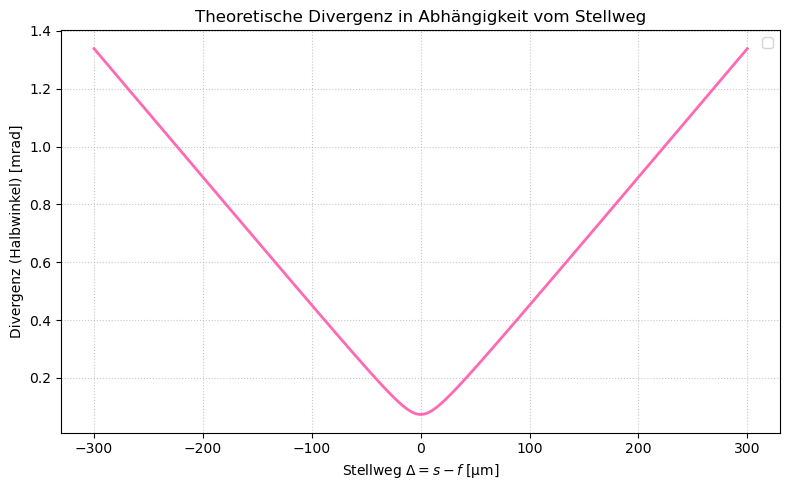

In [35]:
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

lam_eff = M2 * lam  

# Das ist dein Stellweg um den perfekten Fokuspunkt (Delta)
delta = np.linspace(-300*1e-6, 300*1e-6, 1000)
zR = np.pi * wf**2 / lam_eff 

def winkel(delta_wert, brennweite, wf, lam_eff, zR):
    # 1. Den Bruch berechnen
    term1 = lam_eff / (np.pi * brennweite * wf)
    
    # 2. Delta direkt einsetzen (kein -f mehr nötig!)
    theta = np.sqrt(delta_wert**2 + zR**2) * term1
    
    return theta

# Berechnung durchführen
theta_winkel = winkel(delta, f, wf, lam_eff, zR)

plt.figure(figsize=(8, 5))
plt.plot(delta * 1e6, theta_winkel * 1e3, color='hotpink', linewidth=2)

plt.xlabel('Stellweg $\Delta =s-f$ [µm]')
plt.ylabel('Divergenz (Halbwinkel) [mrad]')
plt.title('Theoretische Divergenz in Abhängigkeit vom Stellweg')
plt.grid(True, linestyle=':', alpha=0.7)

# Eine kleine Markierung für das physikalische Minimum
#plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Perfekter Fokus')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

# Abgeleitete Größen
lam_eff = M2 * lam  
zR = np.pi * wf**2 / lam_eff 

# Funktion für den reinen Stellweg (Toleranz Delta)
def berechne_stellweg(theta, brennweite, wf, lam_eff, zR):
    # 1. Den Bruch berechnen
    term = (theta * np.pi * brennweite * wf) / lam_eff
    
    # 2. Die reine Toleranz (Delta) aus der Wurzel ziehen
    delta = np.sqrt(term**2 - zR**2)
    
    return delta

# Deine gewünschte Ziel-Divergenz: 0,20 mrad (0.00020 rad)
theta_ziel = 0.20e-3  

# Berechnung aufrufen
toleranz_delta = berechne_stellweg(theta_ziel, f, wf, lam_eff, zR)

# Ausgabe sauber formatieren
print(f"Ziel-Divergenz: {theta_ziel * 1e3:.2f} mrad")
print(f"Erlaubter Stellweg (Toleranz Delta): +/- {toleranz_delta * 1e6:.1f} µm")





Ziel-Divergenz: 0.20 mrad
Erlaubter Stellweg (Toleranz Delta): +/- 41.7 µm


In [ ]:
#mit zR neu
# 
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor (1.0 = idealer Gaußstrahl)
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

# Effektive Wellenlänge für M²-Strahl
lam_eff = M2 * lam   # [m]  

# Rayleigh-Länge am Faserwaist (mit M²)
zR = np.pi * wf**2 / lam_eff   # [m]

# Delta-Bereich: +/- 1 mm
delta = np.linspace(-1e-3, 1e-3, 1001)
s = f + delta   # Abstand Faser -> Linse [m]

# -----------------------------
# Strahlradius an der Linse
# -----------------------------
w_lens = wf * np.sqrt(1 + (s / zR)**2)
d_lens = 2 * w_lens

# -----------------------------
# q-Parameter vor und nach der Linse
# (ABCD-Transformation unverändert)
# -----------------------------
q1 = s + 1j * zR
q2 = 1 / (1 / q1 - 1 / f)

z_waist = -np.real(q2)   # Neue Waist-Position [m]
zR_new  =  np.imag(q2)   # Neue Rayleigh-Länge  [m]

# Neuer Waist-Radius (mit M²)
w0_new = np.sqrt(lam_eff * zR_new / np.pi)   # 
d0_new = 2 * w0_new

# Divergenz (Halbwinkel, mit M²)
theta      = lam_eff / (np.pi * w0_new)   # [rad]  
theta_mrad = theta * 1e3   



# Funktion für den reinen Stellweg (Toleranz Delta)
def berechne_stellweg(theta, brennweite, wf, lam_eff, zR):
    # 1. Den Bruch berechnen
    term = (theta * np.pi * brennweite * wf) / lam_eff
    
    # 2. Die reine Toleranz (Delta) aus der Wurzel ziehen
    delta = np.sqrt(term**2 - zR**2)
    
    return delta

# Deine gewünschte Ziel-Divergenz: 0,20 mrad (0.00020 rad)
theta_ziel = 0.20e-3  

# Berechnung aufrufen
toleranz_delta = berechne_stellweg(theta_ziel, f, wf, lam_eff, zR)

# Ausgabe sauber formatieren
print(f"Ziel-Divergenz: {theta_ziel * 1e3:.2f} mrad")
print(f"Erlaubter Stellweg (Toleranz Delta): +/- {toleranz_delta * 1e6:.1f} µm")


print(f"4(79) mü {berechne_stellweg(79e-6, f, wf, lam_eff, zR) * 1e6:.1f} µm")
print(f"1000 mü {berechne_stellweg(1080e-6, f, wf, lam_eff, zR) * 1e6:.1f} µm")
print(f"4(79) mü {berechne_stellweg(79e-6, f, wf, lam_eff, zR_new) * 1e6:.1f} µm")
print(f"1000 mü {berechne_stellweg(1080e-6, f, wf, lam_eff, zR_new) * 1e6:.1f} µm")


Ziel-Divergenz: 0.20 mrad
Erlaubter Stellweg (Toleranz Delta): +/- 41.7 µm
4(79) mü 6.3 µm
1000 mü 241.8 µm


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_9258/1481315914.py:57: RuntimeWarning: invalid value encountered in sqrt
  delta = np.sqrt(term**2 - zR**2)


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [ ]:
lam  = 1064e-9   
M2   = 1.3       
MFD  = 5.4e-6    
wf   = MFD / 2   
f    = 36.6e-3   

lam_eff = M2 * lam   
zR_faser = np.pi * wf**2 / lam_eff   # Die feste Rayleigh-Länge VOR der Linse

# ---------------------------------------------------------
# NEUE FUNKTION: Stellweg aus der Rayleigh-Länge NACH der Linse
# ---------------------------------------------------------
def stellweg_aus_zR_neu(zR_ziel, brennweite, zR_faser):
    # Die umgestellte ABCD-Gleichung
    delta = np.sqrt((brennweite**2 * zR_faser) / zR_ziel - zR_faser**2)
    return delta

# ---------------------------------------------------------
# Test-Rechnung
# ---------------------------------------------------------
# Was ist das physikalische Maximum von zR_neu? 
# Das passiert im perfekten Fokus (Delta = 0).
zR_neu_max = (f**2 * zR_faser) / (0**2 + zR_faser**2)
print(f"Das absolut größte zR nach der Linse (bei perfektem Fokus) ist: {zR_neu_max:.3f} m")

# Nehmen wir an, deine Toleranzgrenze ist erreicht, wenn zR_neu auf 50 Meter abfällt:
zR_zielwert = 50.0  # in Metern

toleranz = stellweg_aus_zR_neu(zR_zielwert, f, zR_faser)
print(f"Um ein zR_neu von {zR_zielwert} m zu erhalten, beträgt der Stellweg: +/- {toleranz * 1e6:.1f} µm")

Das absolut größte zR nach der Linse (bei perfektem Fokus) ist: 80.904 m
Um ein zR_neu von 50.0 m zu erhalten, beträgt der Stellweg: +/- 13.0 µm


In [ ]:
#29.july, 01:47 vieles nochmal neu:
#jetzt berechne fromel winkel mit zR etc alles neu
lam  = 1064e-9   
M2   = 1.3       
MFD  = 5.4e-6    
wf   = MFD / 2   
f    = 36.6e-3   

lam_eff = M2 * lam  
zR = np.pi * wf**2 / lam_eff 

# delta ist die mechanische Verschiebung (s - f)
delta = np.linspace(-300*1e-6, 300*1e-6, 1000) 

def theta(lam_eff, f, delta, zR):
    winkel = np.sqrt((lam_eff / np.pi) * (delta**2 + zR**2) / (f**2 * zR))
    return winkel

def stellweg(lam_eff, f, theta, zR):
    weg = np.sqrt(theta**2 * (np.pi / lam_eff) * f**2 * zR - zR**2)
    return weg

print(stellweg(lam_eff, f, (73.8)*1e-6, zR))
#code sieht gut aus


4.6836112375509836e-07
nan
4.6836112375509835e-08


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_9258/3740241484.py:20: RuntimeWarning: invalid value encountered in sqrt
  weg = np.sqrt(theta**2 * (np.pi / lam_eff) * f**2 * zR - zR**2)
